In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_validate

In [17]:
df = pd.read_pickle("../Data/df_ready.pkl")
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,is_promotion,competitor_pricing,seasonality,is_epidemic,demand,year,month,day,day_of_week
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129,2022,1,1,Saturday
28,2022-01-01,S002,P0009,Groceries,South,131,131,260,64.84,10,Cloudy,0,68.68,Winter,0,145,2022,1,1,Saturday
48,2022-01-01,S003,P0009,Groceries,East,226,96,0,56.32,5,Sunny,0,66.33,Winter,0,126,2022,1,1,Saturday
68,2022-01-01,S004,P0009,Clothing,West,206,106,299,110.47,5,Snowy,0,122.04,Winter,0,98,2022,1,1,Saturday
88,2022-01-01,S005,P0009,Groceries,North,270,59,268,94.75,0,Snowy,0,112.34,Winter,0,94,2022,1,1,Saturday


In [18]:
df.dtypes

date                  datetime64[us]
store_id                    category
product_id                       str
category                    category
region                      category
inventory_level                int64
units_sold                     int64
units_ordered                  int64
price                        float64
discount                       int64
weather_condition           category
is_promotion                category
competitor_pricing           float64
seasonality                 category
is_epidemic                 category
demand                         int64
year                           int32
month                          int32
day                            int32
day_of_week                 category
dtype: object

In [19]:
# Drop Columns
df = df.drop( columns=["store_id", "product_id", "region", "units_sold"])

In [20]:
X = pd.get_dummies(df.drop(columns=["date", "demand"]), drop_first=True)
y = df["demand"]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [21]:
pipelines = {
    "Baseline (Media)": Pipeline([
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Regresión Lineal + StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Decision Tree": Pipeline([
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("model", XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
}

print(f"Modelos de regresión a comparar: {len(pipelines)}")
for name in pipelines:
    print(f"  - {name}")

Modelos de regresión a comparar: 5
  - Baseline (Media)
  - Regresión Lineal + StandardScaler
  - Decision Tree
  - Random Forest
  - XGBoost


In [22]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

scoring_metrics = [
    "neg_mean_absolute_error",
    "neg_mean_absolute_percentage_error",
    "neg_root_mean_squared_error",
    "r2"
]

for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring_metrics, n_jobs=-1)
    cv_rows.append({
        "Modelo": name,
        "MAE CV": -scores["test_neg_mean_absolute_error"].mean(),
        "MAPE CV": -scores["test_neg_mean_absolute_percentage_error"].mean(),
        "RMSE CV": -scores["test_neg_root_mean_squared_error"].mean(),
        "R2 CV": scores["test_r2"].mean()
    })

df_cv = pd.DataFrame(cv_rows).sort_values("MAE CV", ascending=True)
print(df_cv.to_string(index=False))

                           Modelo    MAE CV  MAPE CV   RMSE CV     R2 CV
                    Random Forest 13.717464 0.164359 20.288852  0.765977
                          XGBoost 14.065061 0.166662 20.480944  0.761252
                    Decision Tree 18.469297 0.203528 28.280923  0.545958
Regresión Lineal + StandardScaler 24.087250 0.284300 29.885229  0.492637
                 Baseline (Media) 33.958867 0.427423 42.039229 -0.002613


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score
)

rows = []
for name, pipe in pipelines.items():
    X_tr, X_te = X_train, X_test
    pipe.fit(X_tr, y_train)
    y_p = pipe.predict(X_te)
    
    rows.append({
        "Modelo": name,
        "MAE": mean_absolute_error(y_test, y_p),
        "MAPE": mean_absolute_percentage_error(y_test, y_p),
        "RMSE": root_mean_squared_error(y_test, y_p),
        "R2": r2_score(y_test, y_p)
    })

df_compare = pd.DataFrame(rows).sort_values("MAE", ascending=True)
print(df_compare.to_string(index=False))

                           Modelo       MAE     MAPE      RMSE        R2
                    Random Forest 13.823137 0.149075 20.316739  0.766384
                          XGBoost 14.497049 0.156291 21.208353  0.745429
                    Decision Tree 18.101877 0.185529 28.866894  0.528378
Regresión Lineal + StandardScaler 24.187221 0.263090 29.853176  0.495600
                 Baseline (Media) 34.587871 0.409204 42.051856 -0.000840


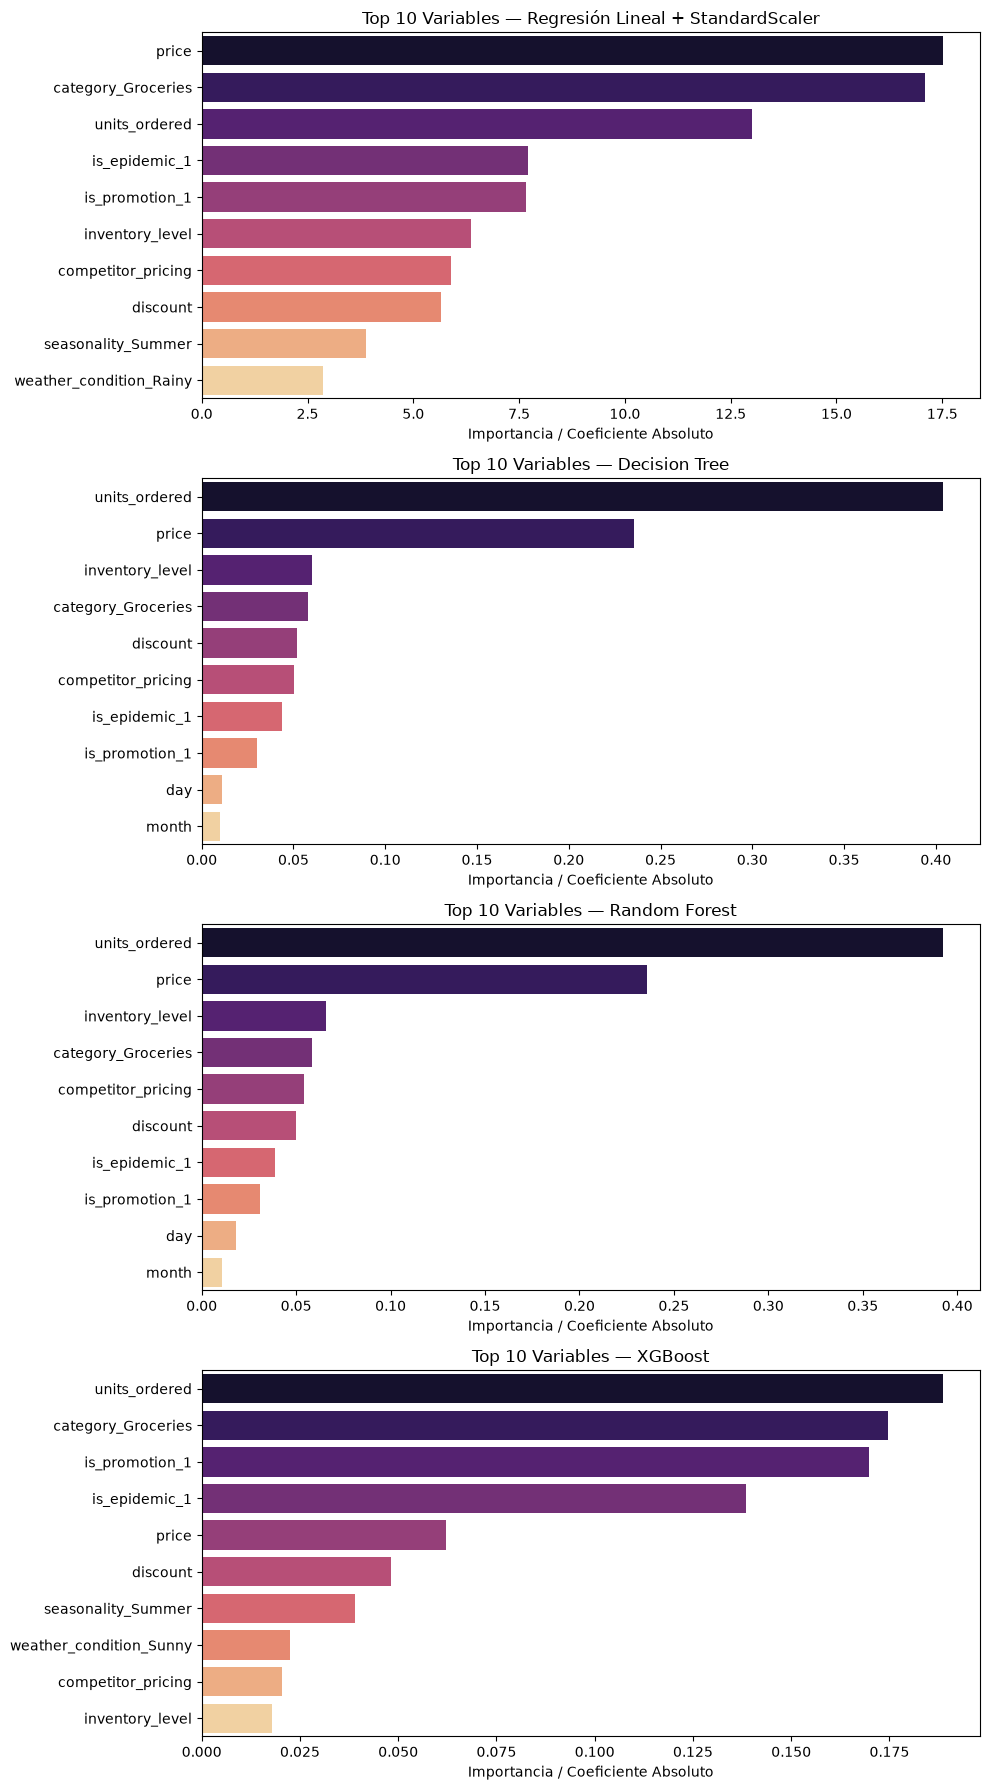

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pipelines_vis = {k: v for k, v in pipelines.items() if "Baseline" not in k}
fig, axes = plt.subplots(len(pipelines_vis), 1, figsize=(10, 18))

for i, (name, pipe) in enumerate(pipelines_vis.items()):
    model = pipe.named_steps["model"]
    imps = (
        np.abs(model.coef_)
        if "Regresión Lineal" in name
        else model.feature_importances_
    )

    feat_imp = pd.DataFrame({"Variable": X.columns, "Importancia": imps})
    top10 = feat_imp.sort_values("Importancia", ascending=False).head(10)

    sns.barplot(
        data=top10,
        x="Importancia",
        y="Variable",
        hue="Variable",
        palette="magma",
        legend=False,
        ax=axes[i],
    )
    axes[i].set_title(f"Top 10 Variables — {name}")
    axes[i].set(xlabel="Importancia / Coeficiente Absoluto", ylabel="")

plt.tight_layout()
plt.show()